# Template matching

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplolib inline

UsageError: Line magic function `%matplolib` not found.


In [2]:
full = cv2.imread('../DATA/sammy.jpg')
full = cv2.cvtColor(full, cv2.COLOR_BGR2RGB)

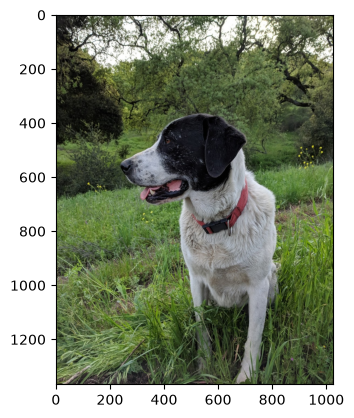

In [3]:
plt.imshow(full)

In [6]:
full.shape

(1367, 1025, 3)

In [4]:
face = cv2.imread('../DATA/sammy_face.jpg')
face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)

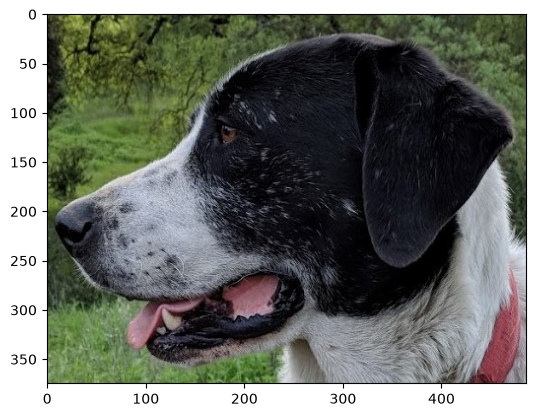

In [5]:
plt.imshow(face)

In [7]:
face.shape

(375, 486, 3)

In [8]:
sum([1, 2, 3])

6

In [10]:
mystring = 'sum'

In [11]:
eval(mystring)

<function sum(iterable, /, start=0)>

In [12]:
myfunc = eval(mystring)

In [13]:
myfunc([1, 2, 3])

6

In [14]:
methods = [
    'cv2.TM_CCOEFF', 
    'cv2.TM_CCOEFF_NORMED', 
    'cv2.TM_CCORR',
    'cv2.TM_CCORR_NORMED', 
    'cv2.TM_SQDIFF', 
    'cv2.TM_SQDIFF_NORMED'
    ]

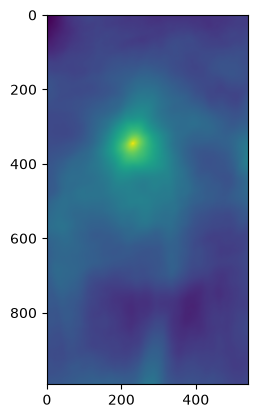

In [19]:
my_method = eval('cv2.TM_CCOEFF')
res = cv2.matchTemplate(full, face, my_method)

plt.imshow(res)

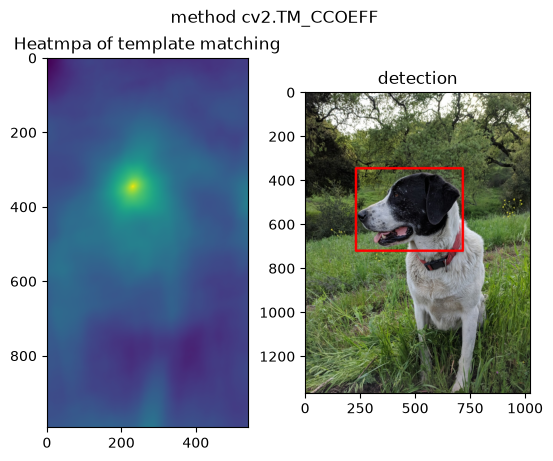

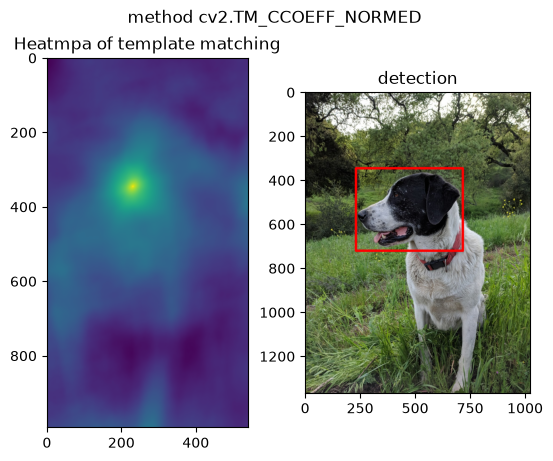

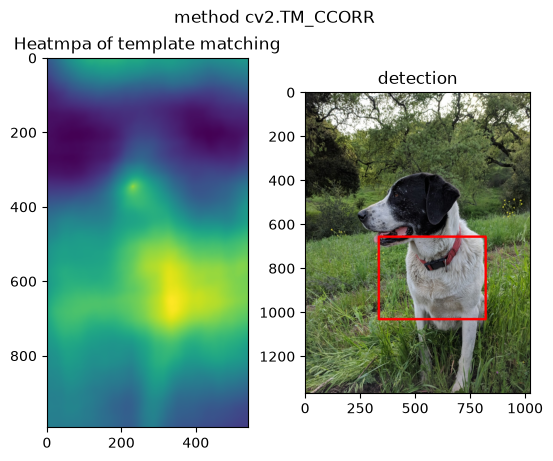

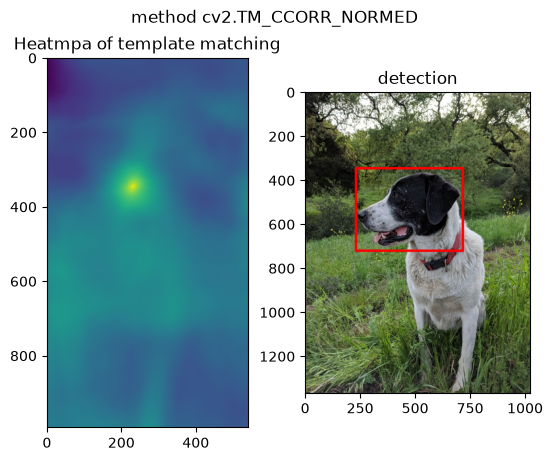

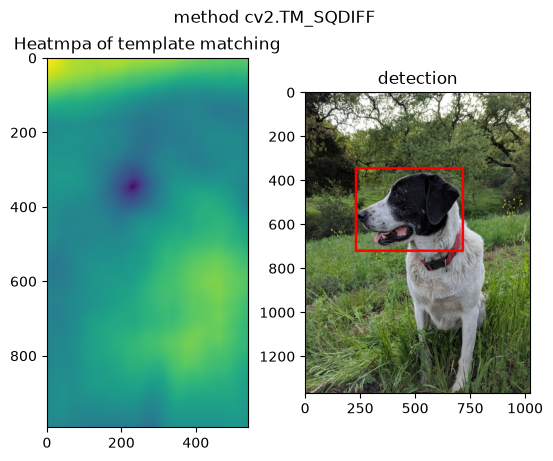

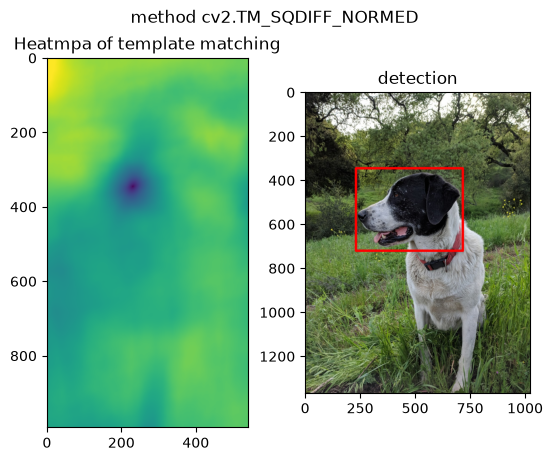

In [22]:
for m in methods:
    
    # Create a copy
    full_copy = full.copy()
    
    method = eval(m)
    
    # Template matching
    res = cv2.matchTemplate(full_copy, face, method)
    
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)
    
    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc
        
    height, width, channels = face.shape
    
    bottom_right = (top_left[0] + width, top_left[1] + height)
    
    cv2.rectangle(full_copy, top_left, bottom_right, (255, 0, 0), 10)
    
    # plot and show
    plt.subplot(121)
    plt.imshow(res)
    plt.title('Heatmpa of template matching')
    
    plt.subplot(122)
    plt.imshow(full_copy)
    plt.title('detection')
    plt.suptitle(f"method {m}")
    
    plt.show()
    
    print('\n')
    print('\n')
    

# Edge detection

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplolib inline

UsageError: Line magic function `%matplolib` not found.


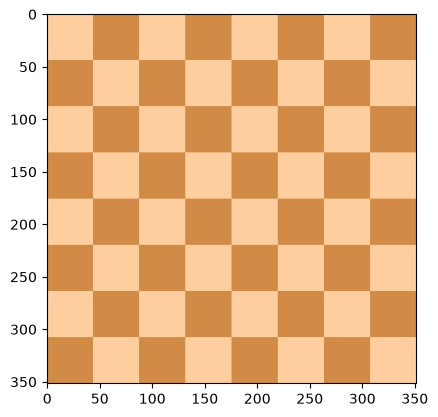

In [25]:
flat_chess = cv2.imread('../DATA/flat_chessboard.png')
flat_chess = cv2.cvtColor(flat_chess, cv2.COLOR_BGR2RGB)

plt.imshow(flat_chess)

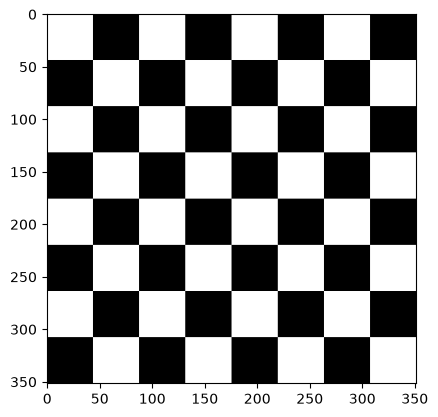

In [26]:
gray_flat_chess = cv2.cvtColor(flat_chess, cv2.COLOR_RGB2GRAY)
plt.imshow(gray_flat_chess, cmap='gray')

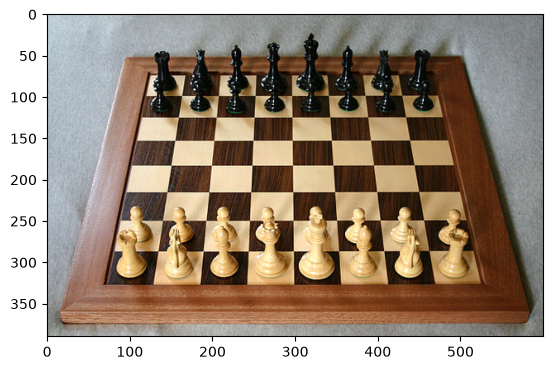

In [28]:
real_chess = cv2.imread('../DATA/real_chessboard.jpg', cv2.IMREAD_COLOR_RGB)
plt.imshow(real_chess)

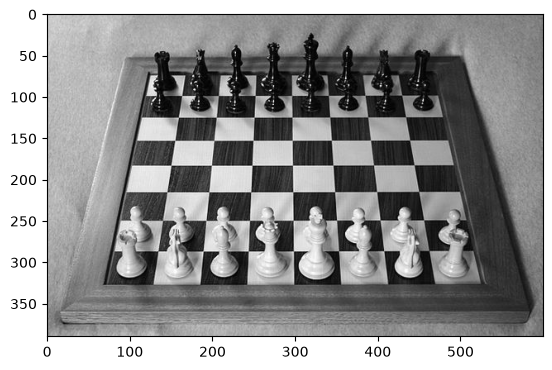

In [29]:
gray_real_chess = cv2.cvtColor(real_chess, cv2.COLOR_RGB2GRAY)
plt.imshow(gray_real_chess, cmap="gray")

In [31]:
gray = np.float32(gray_flat_chess)

In [34]:
dst = cv2.cornerHarris(src=gray, blockSize=3, ksize=3, k=0.04)

In [35]:
dst = cv2.dilate(dst, None)

In [36]:
flat_chess[dst>0.01*dst.max()] = [255, 0, 0]

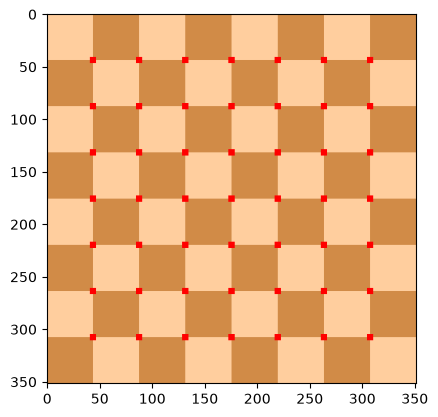

In [38]:
plt.imshow(flat_chess)

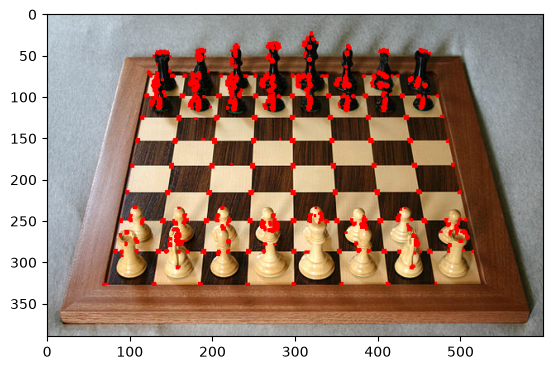

In [40]:
gray = np.float32(gray_real_chess)

dst = cv2.cornerHarris(src=gray, blockSize=3, ksize=3, k=0.04)

dst = cv2.dilate(dst, None)

real_chess[dst > 0.01 * dst.max()] = [255, 0, 0]

plt.imshow(real_chess)

In [41]:
flat_chess = cv2.imread('../DATA/flat_chessboard.png')
flat_chess = cv2.cvtColor(flat_chess,cv2.COLOR_BGR2RGB)
gray_flat_chess = cv2.cvtColor(flat_chess,cv2.COLOR_BGR2GRAY)

real_chess = cv2.imread('../DATA/real_chessboard.jpg')
real_chess = cv2.cvtColor(real_chess,cv2.COLOR_BGR2RGB)
gray_real_chess = cv2.cvtColor(real_chess,cv2.COLOR_BGR2GRAY)

In [ ]:
corners = cv2.goodFeaturesToTrack(gray_flat_chess, 5, 0.01, 10)

In [48]:
corners = np.intp(corners)
corners

array([[[308, 308]],

       [[264, 308]],

       [[220, 308]],

       [[176, 308]],

       [[132, 308]]])

In [49]:
for i in corners:
    
    x, y = i.ravel()
    cv2.circle(flat_chess, (x, y), 3, (255, 0, 0), -1)

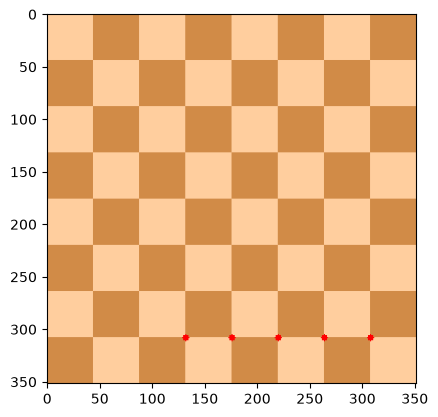

In [50]:
plt.imshow(flat_chess)

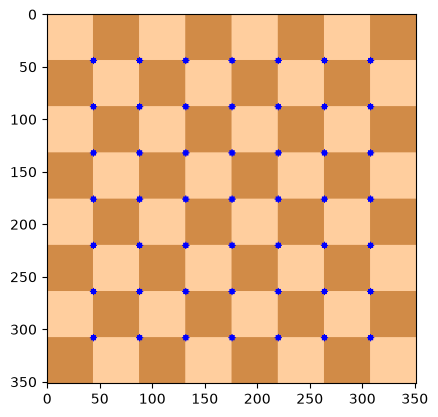

In [51]:
corners = cv2.goodFeaturesToTrack(gray_flat_chess, 64, 0.01, 10)
corners = np.intp(corners)
for i in corners:
    x, y = i.ravel()
    cv2.circle(flat_chess, (x, y), 3, (0, 0, 255), -1)
plt.imshow(flat_chess)

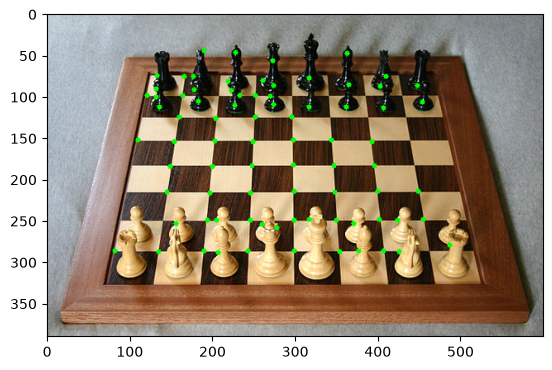

In [52]:
corners = cv2.goodFeaturesToTrack(gray_real_chess, 80, 0.01, 10)
corners = np.intp(corners)
for i in corners:
    x, y = i.ravel()
    cv2.circle(real_chess, (x,y), 3, (0, 255, 0), -1)
plt.imshow(real_chess)